In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import mglearn
from sklearn.model_selection import train_test_split

**Membuat dataset sintetis 'forge' untuk klasifikasi**

In [6]:
X, y = mglearn.datasets.make_forge()

**Visualisasi dataset**

X.shape: (26, 2)


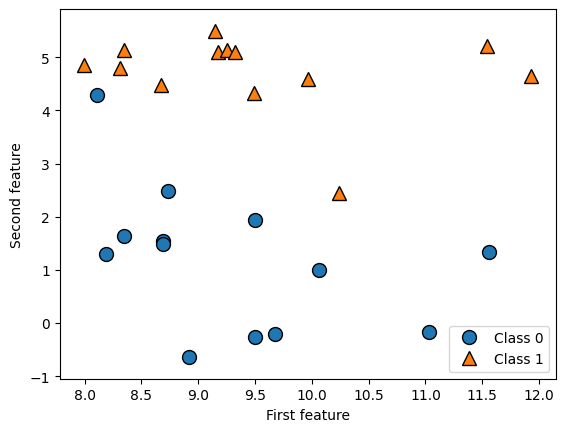

In [7]:
mglearn.discrete_scatter(X[:, 0], X[:, 1], y)
plt.legend(["Class 0", "Class 1"], loc=4)
plt.xlabel("First feature")
plt.ylabel("Second feature")
print(f"X.shape: {X.shape}")

Dataset forge adalah data buatan dengan dua fitur untuk mempermudah visualisasi klasifikasi biner

**Dataset Sintetis untuk Regresi (Wave)**

Text(0, 0.5, 'Target')

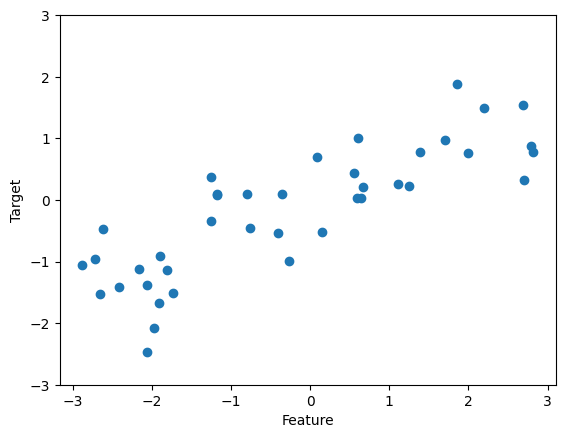

In [8]:
X_wave, y_wave = mglearn.datasets.make_wave(n_samples=40)
plt.plot(X_wave, y_wave, 'o')
plt.ylim(-3, 3)
plt.xlabel("Feature")
plt.ylabel("Target")

Dataset wave digunakan untuk tugas regresi, di mana target yang diprediksi adalah nilai kontinu (angka), bukan label kategori

**Memuat Dataset Dunia Nyata (Breast Cancer)**

In [9]:
from sklearn.datasets import load_breast_cancer
cancer = load_breast_cancer()
print(f"Bentuk data cancer: {cancer.data.shape}")
print(f"Hitungan sampel per kelas:\n{ {n: v for n, v in zip(cancer.target_names, np.bincount(cancer.target))} }")

Bentuk data cancer: (569, 30)
Hitungan sampel per kelas:
{np.str_('malignant'): np.int64(212), np.str_('benign'): np.int64(357)}


Dataset ini berisi data medis untuk memprediksi apakah tumor bersifat ganas (malignant) atau jinak (benign). Memahami distribusi kelas penting untuk mendeteksi ketidakseimbangan data


**k-Nearest Neighbors (k-NN) Classification**

In [10]:
from sklearn.neighbors import KNeighborsClassifier
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

clf = KNeighborsClassifier(n_neighbors=3)
clf.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

k-NN adalah algoritma paling sederhana yang memprediksi label berdasarkan mayoritas label tetangga terdekatnya

**Mengevaluasi Prediksi k-NN**

In [11]:
print(f"Prediksi test set: {clf.predict(X_test)}")
print(f"Akurasi test set: {clf.score(X_test, y_test):.2f}")

Prediksi test set: [1 0 1 0 1 0 0]
Akurasi test set: 0.86


Data tes untuk melihat seberapa baik model melakukan generalisasi. Akurasi 0.86 berarti model benar 86% kali

**Visualisasi Decision Boundary k-NN**

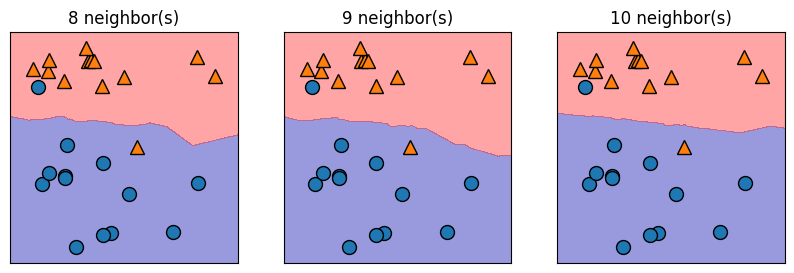

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(10, 3))

for n_neighbors, ax in zip([8, 9, 10], axes):
    clf = KNeighborsClassifier(n_neighbors=n_neighbors).fit(X, y)

    mglearn.plots.plot_2d_separator(
        clf, X, fill=True, eps=0.5, ax=ax, alpha=.4
    )

    mglearn.discrete_scatter(X[:, 0], X[:, 1], y, ax=ax)

    ax.set_title(f"{n_neighbors} neighbor(s)")

plt.show()

Semakin kecil nilai n_neighbors, semakin kompleks batas keputusannya (berisiko overfitting). Semakin besar nilainya, batas keputusan semakin halus (simpler model)

**Analisis Overfitting pada KNN (Dataset Cancer)**

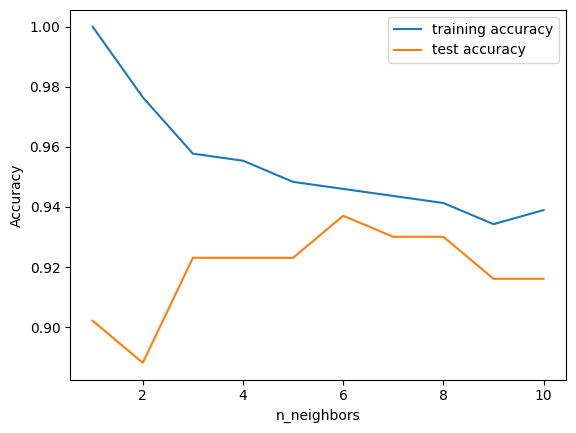

In [14]:
training_accuracy = []
test_accuracy = []
neighbors_settings = range(1, 11)

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    cancer.data, cancer.target, stratify=cancer.target, random_state=66)

for n_neighbors in neighbors_settings:
    clf = KNeighborsClassifier(n_neighbors=n_neighbors)
    clf.fit(X_train_c, y_train_c)
    training_accuracy.append(clf.score(X_train_c, y_train_c))
    test_accuracy.append(clf.score(X_test_c, y_test_c))

plt.plot(neighbors_settings, training_accuracy, label="training accuracy")
plt.plot(neighbors_settings, test_accuracy, label="test accuracy")
plt.ylabel("Accuracy")
plt.xlabel("n_neighbors")
plt.legend()

Pada n_neighbors=1, akurasi training sempurna (100%) tapi akurasi test rendah, menandakan overfitting

**k-Nearest Neighbors Regression**

In [15]:
from sklearn.neighbors import KNeighborsRegressor

X_train_w, X_test_w, y_train_w, y_test_w = train_test_split(X_wave, y_wave, random_state=0)
reg = KNeighborsRegressor(n_neighbors=3)
reg.fit(X_train_w, y_train_w)

KNeighborsRegressor(n_neighbors=3)

Untuk regresi, k-NN menghitung rata-rata nilai target dari tetangga terdekatnya

**Evaluasi R^2 pada k-NN Regression**

In [16]:
print(f"Test set R^2 score: {reg.score(X_test_w, y_test_w):.2f}")

Test set R^2 score: 0.83


Skor R^2 (koefisien determinasi) mengukur seberapa baik model menjelaskan variasi data. Skor 1.0 berarti prediksi sempurna.

**Linear Regression (Ordinary Least Squares)**

In [17]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression().fit(X_train_w, y_train_w)

print(f"lr.coef_: {lr.coef_}")
print(f"lr.intercept_: {lr.intercept_}")

lr.coef_: [0.52424272]
lr.intercept_: -0.09394309015377249


Regresi linear mencari garis lurus yang meminimalkan kesalahan kuadrat antara prediksi dan target asli

**Ridge Regression (Regularization L2)**

In [18]:
from sklearn.linear_model import Ridge
# Memuat data perumahan Boston yang telah diperluas fiturnya
X_b, y_b = mglearn.datasets.load_extended_boston()
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(X_b, y_b, random_state=0)

ridge = Ridge().fit(X_train_b, y_train_b)
print(f"Ridge Test Score: {ridge.score(X_test_b, y_test_b):.2f}")

Ridge Test Score: 0.75


Ridge menggunakan regulasi L2 untuk mencegah overfitting dengan memaksa koefisien fitur mendekati nol

**Pengaruh Alpha pada Ridge**

In [20]:
ridge10 = Ridge(alpha=10).fit(X_train_b, y_train_b)
ridge01 = Ridge(alpha=0.1).fit(X_train_b, y_train_b)

print(f"Ridge alpha=10 Test Score: {ridge10.score(X_test_b, y_test_b):.2f}")
print(f"Ridge alpha=0.1 Test Score: {ridge01.score(X_test_b, y_test_b):.2f}")


Ridge alpha=10 Test Score: 0.64
Ridge alpha=0.1 Test Score: 0.77


Parameter alpha mengontrol kekuatan regulasi. Semakin besar alpha, semakin simpel modelnya (menuju underfitting)

**Lasso Regression (Regularization L1)**

In [21]:
from sklearn.linear_model import Lasso
lasso = Lasso().fit(X_train_b, y_train_b)

print(f"Lasso Test Score: {lasso.score(X_test_b, y_test_b):.2f}")
print(f"Jumlah fitur yang digunakan: {np.sum(lasso.coef_ != 0)}")

Lasso Test Score: 0.21
Jumlah fitur yang digunakan: 4


Lasso menggunakan regulasi L1 yang mampu membuat koefisien fitur tertentu menjadi nol tepat, sehingga berfungsi sebagai seleksi fitur otomatis

**Logistic Regression untuk Klasifikasi**

In [22]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(max_iter=10000).fit(X_train_c, y_train_c)
print(f"LogReg Training Score: {logreg.score(X_train_c, y_train_c):.3f}")
print(f"LogReg Test Score: {logreg.score(X_test_c, y_test_c):.3f}")


LogReg Training Score: 0.979
LogReg Test Score: 0.944


**Linear Support Vector Machines (LinearSVC)**

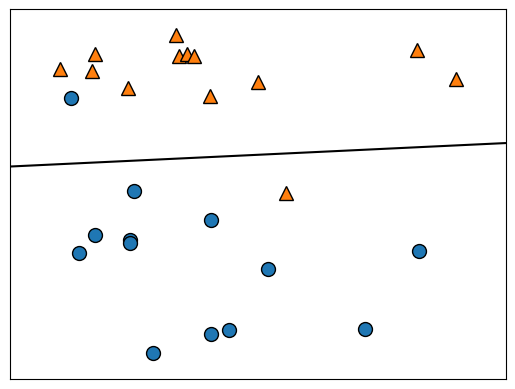

In [24]:
from sklearn.svm import LinearSVC
linear_svm = LinearSVC(max_iter=10000).fit(X, y)

mglearn.plots.plot_2d_separator(linear_svm, X, fill=False, eps=0.5)
mglearn.discrete_scatter(X[:, 0], X[:, 1], y)

VM linier mencoba mencari "hyperplane" atau garis pemisah terbaik dengan margin maksimal antara dua kelas

**Naive Bayes Classifiers**

In [25]:
from sklearn.naive_bayes import GaussianNB
gnb = GaussianNB().fit(X_train_c, y_train_c)
print(f"Akurasi Naive Bayes: {gnb.score(X_test_c, y_test_c):.2f}")

Akurasi Naive Bayes: 0.92


**Decision Tree Classifier**

In [26]:
from sklearn.tree import DecisionTreeClassifier
tree = DecisionTreeClassifier(random_state=0)
tree.fit(X_train_c, y_train_c)
print(f"Akurasi Training (Unpruned): {tree.score(X_train_c, y_train_c):.3f}")

Akurasi Training (Unpruned): 1.000


Pohon keputusan belajar melalui hirarki pertanyaan if/else. Tanpa pembatasan (unpruned), model ini cenderung menghafal data training (overfit)

**Pre-Pruning pada Decision Tree**

In [27]:
tree4 = DecisionTreeClassifier(max_depth=4, random_state=0)
tree4.fit(X_train_c, y_train_c)
print(f"Akurasi Test (Pruned): {tree4.score(X_test_c, y_test_c):.3f}")

Akurasi Test (Pruned): 0.902


Membatasi kedalaman pohon (max_depth) adalah bentuk pre-pruning untuk meningkatkan generalisasi


**Random Forest (Ensemble Learning)**

In [28]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=100, random_state=0)
rf.fit(X_train_c, y_train_c)
print(f"Akurasi Random Forest: {rf.score(X_test_c, y_test_c):.3f}")

Akurasi Random Forest: 0.958


Random Forest menggabungkan banyak pohon keputusan acak untuk mengurangi overfitting


** Gradient Boosted Decision Trees (GBDT)**

In [29]:
from sklearn.ensemble import GradientBoostingClassifier
gbrt = GradientBoostingClassifier(random_state=0)
gbrt.fit(X_train_c, y_train_c)
print(f"Akurasi GBDT: {gbrt.score(X_test_c, y_test_c):.3f}")

Akurasi GBDT: 0.958


GBDT membangun pohon secara berurutan, di mana setiap pohon baru mencoba memperbaiki kesalahan pohon sebelumnya

**Kernelized Support Vector Machines (RBF Kernel)**

In [30]:
from sklearn.svm import SVC
svm = SVC(kernel='rbf', C=1, gamma=0.1).fit(X_train_c, y_train_c)
print(f"Akurasi SVM: {svm.score(X_test_c, y_test_c):.2f}")

Akurasi SVM: 0.63


SVM dengan kernel RBF mampu menangani dataset yang tidak bisa dipisahkan secara linier dengan memetakan data ke dimensi yang lebih tinggi


**Preprocessing Data untuk SVM**

In [31]:
min_on_training = X_train_c.min(axis=0)
range_on_training = (X_train_c - min_on_training).max(axis=0)

X_train_scaled = (X_train_c - min_on_training) / range_on_training
X_test_scaled = (X_test_c - min_on_training) / range_on_training

svm_scaled = SVC().fit(X_train_scaled, y_train_c)
print(f"Akurasi SVM setelah scaling: {svm_scaled.score(X_test_scaled, y_test_c):.3f}")

Akurasi SVM setelah scaling: 0.972


SVM sangat sensitif terhadap skala fitur. Scaling data ke rentang 0-1 sangat meningkatkan performa model ini

**Neural Networks (Multilayer Perceptrons)**

In [32]:
from sklearn.neural_network import MLPClassifier
mlp = MLPClassifier(random_state=42, max_iter=1000).fit(X_train_scaled, y_train_c)
print(f"Akurasi Neural Network: {mlp.score(X_test_scaled, y_test_c):.3f}")

Akurasi Neural Network: 0.958


** Memeriksa Ketidakpastian Prediksi (predict_proba)**

In [33]:
print(f"Probabilitas kelas:\n{gbrt.predict_proba(X_test_c[:5])}")

Probabilitas kelas:
[[1.68557164e-04 9.99831443e-01]
 [1.58743522e-04 9.99841256e-01]
 [2.43172031e-04 9.99756828e-01]
 [1.54955322e-04 9.99845045e-01]
 [2.20335675e-04 9.99779664e-01]]
